# Heart Disease Prediction — Exploratory Data Analysis
AdaBoost Classifier | Heart Disease Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Load Dataset

In [2]:
df = pd.read_csv('../data/heart_disease.csv')
print('Shape:', df.shape)
df.head(10)

Shape: (2000, 14)


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate,exercise_angina,oldpeak,slope,ca,thal,heart_disease
0,68,0,0,166,332,0,0,93,0,1.3,2,4,1,1
1,58,0,1,134,396,0,1,146,0,1.2,0,4,1,1
2,44,0,2,168,363,1,2,145,1,1.0,2,0,1,0
3,72,1,0,109,234,1,1,138,0,4.7,2,0,2,1
4,37,0,0,153,175,1,2,170,1,1.4,2,4,2,0
5,50,1,0,182,381,1,0,161,1,3.2,1,4,1,1
6,68,0,3,195,234,0,0,161,1,2.7,1,0,2,0
7,48,0,1,182,302,0,0,99,1,3.5,0,0,1,1
8,52,0,1,156,382,0,0,87,1,5.3,0,1,2,1
9,40,1,2,172,214,1,2,113,0,5.2,1,1,0,0


In [3]:
df.info()
print('\nNull values:')
print(df.isnull().sum())
print('\nDuplicates:', df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  2000 non-null   int64  
 1   sex                  2000 non-null   int64  
 2   chest_pain_type      2000 non-null   int64  
 3   resting_bp           2000 non-null   int64  
 4   cholesterol          2000 non-null   int64  
 5   fasting_blood_sugar  2000 non-null   int64  
 6   rest_ecg             2000 non-null   int64  
 7   max_heart_rate       2000 non-null   int64  
 8   exercise_angina      2000 non-null   int64  
 9   oldpeak              2000 non-null   float64
 10  slope                2000 non-null   int64  
 11  ca                   2000 non-null   int64  
 12  thal                 2000 non-null   int64  
 13  heart_disease        2000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 218.9 KB

Null values:
age                    0
s

In [4]:
df.describe().T.style.background_gradient(cmap='Reds')

,count,mean,std,min,25%,50%,75%,max
age,2000.000000,54.760000,14.270046,30.000000,42.000000,55.000000,67.000000,79.000000
sex,2000.000000,0.516500,0.499853,0.000000,0.000000,1.000000,1.000000,1.000000
chest_pain_type,2000.000000,1.456500,1.125496,0.000000,0.000000,1.000000,2.000000,3.000000
resting_bp,2000.000000,144.621000,31.399320,90.000000,117.000000,145.000000,172.000000,199.000000
cholesterol,2000.000000,273.074500,71.353378,150.000000,214.000000,272.000000,334.000000,399.000000
fasting_blood_sugar,2000.000000,0.508000,0.500061,0.000000,0.000000,1.000000,1.000000,1.000000
rest_ecg,2000.000000,0.952500,0.823154,0.000000,0.000000,1.000000,2.000000,2.000000
max_heart_rate,2000.000000,134.259500,37.573409,70.000000,101.750000,134.500000,167.000000,199.000000
exercise_angina,2000.000000,0.519000,0.499764,0.000000,0.000000,1.000000,1.000000,1.000000
oldpeak,2000.000000,3.007400,1.745998,0.000000,1.500000,3.000000,4.500000,6.000000


## 2. Target Distribution

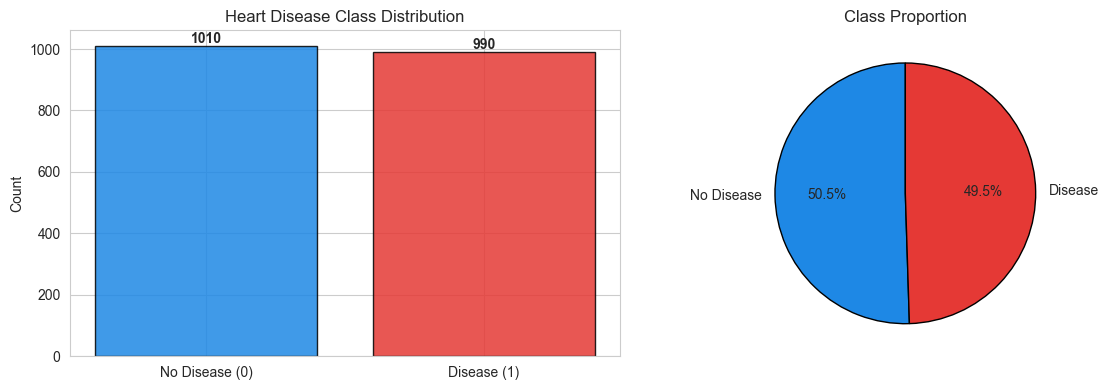

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['heart_disease'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values,
            color=['#1E88E5', '#E53935'], edgecolor='black', alpha=0.85)
axes[0].set_title('Heart Disease Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+10, str(v), ha='center', fontweight='bold')
axes[1].pie(counts.values, labels=['No Disease', 'Disease'],
            autopct='%1.1f%%', colors=['#1E88E5', '#E53935'],
            startangle=90, wedgeprops=dict(edgecolor='black'))
axes[1].set_title('Class Proportion')
plt.tight_layout()
plt.show()

## 3. Numerical Feature Distributions

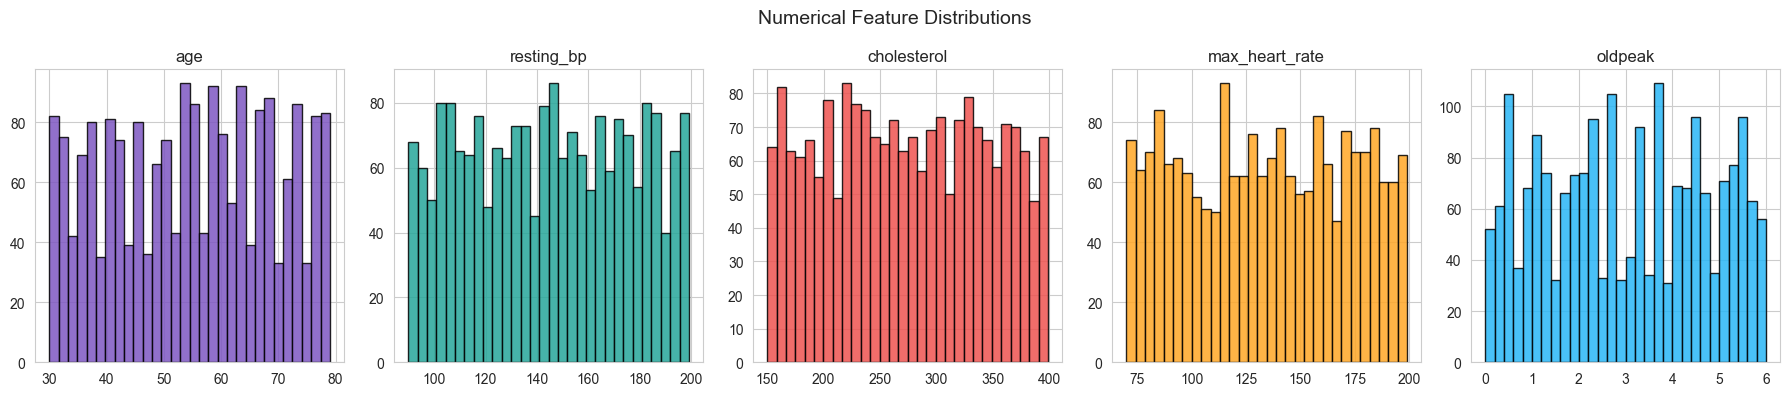

In [6]:
num_cols = ['age', 'resting_bp', 'cholesterol', 'max_heart_rate', 'oldpeak']
palette = ['#7E57C2', '#26A69A', '#EF5350', '#FFA726', '#29B6F6']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col, color in zip(axes, num_cols, palette):
    ax.hist(df[col], bins=30, color=color, edgecolor='black', alpha=0.85)
    ax.set_title(col)
plt.suptitle('Numerical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Feature Distributions by Heart Disease Status

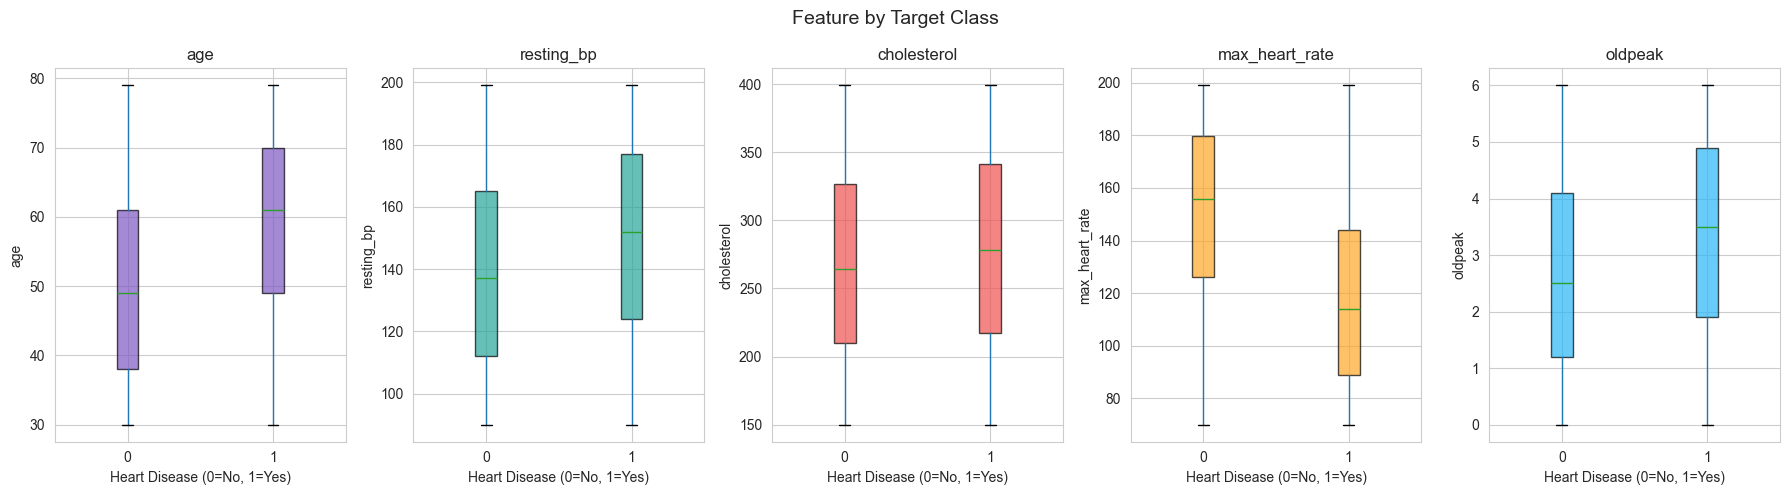

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, col, color in zip(axes, num_cols, palette):
    df.boxplot(column=col, by='heart_disease', ax=ax, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7))
    ax.set_xlabel('Heart Disease (0=No, 1=Yes)')
    ax.set_ylabel(col)
    plt.sca(ax); plt.title(col)
plt.suptitle('Feature by Target Class', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Categorical Feature Analysis

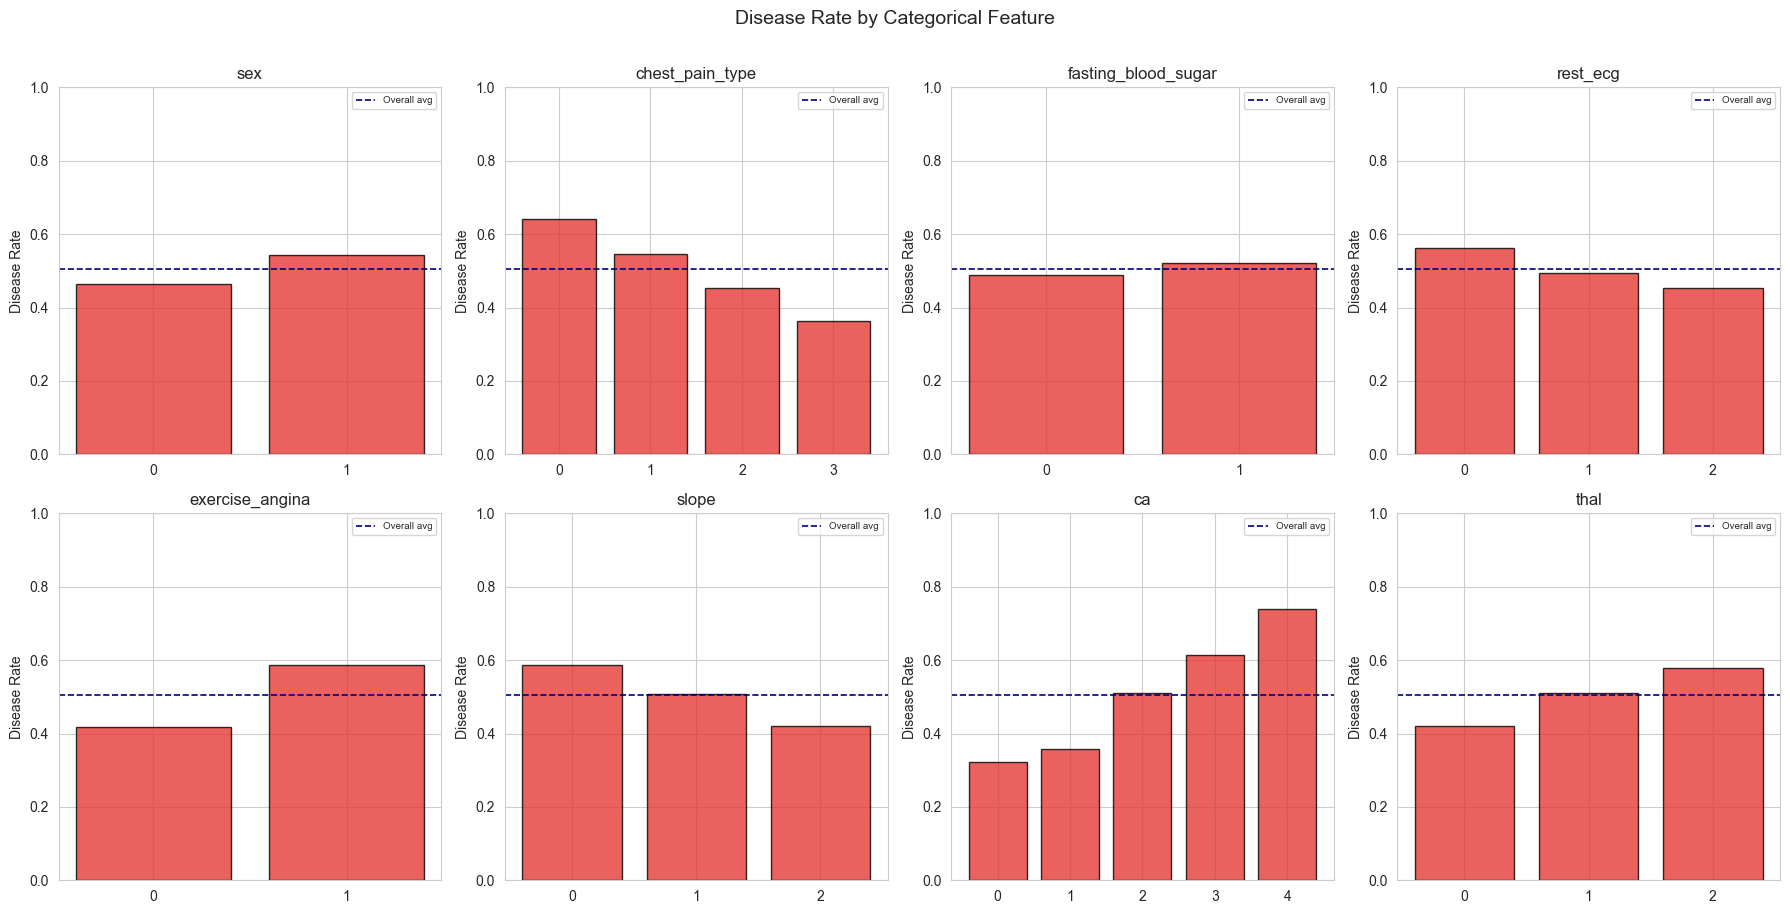

In [8]:
cat_cols = ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg',
            'exercise_angina', 'slope', 'ca', 'thal']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, col in zip(axes.flat, cat_cols):
    rate = df.groupby(col)['heart_disease'].mean()
    ax.bar(rate.index.astype(str), rate.values,
           color='#E53935', edgecolor='black', alpha=0.8)
    ax.axhline(df['heart_disease'].mean(), color='navy',
               linestyle='--', linewidth=1.2, label='Overall avg')
    ax.set_title(col)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Disease Rate')
    ax.legend(fontsize=7)
plt.suptitle('Disease Rate by Categorical Feature', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

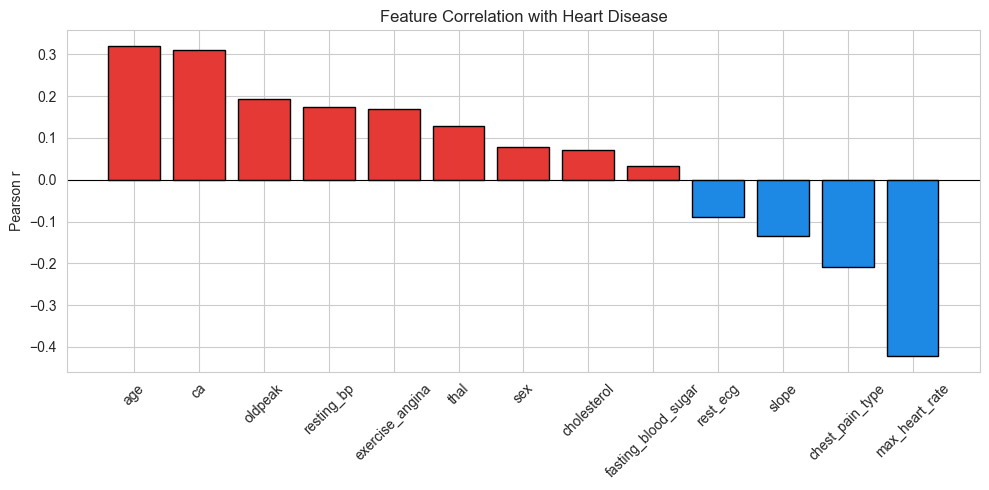

In [9]:
corr = df.corr()['heart_disease'].drop('heart_disease').sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E53935' if v > 0 else '#1E88E5' for v in corr]
ax.bar(corr.index, corr.values, color=colors, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Heart Disease')
ax.set_ylabel('Pearson r')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

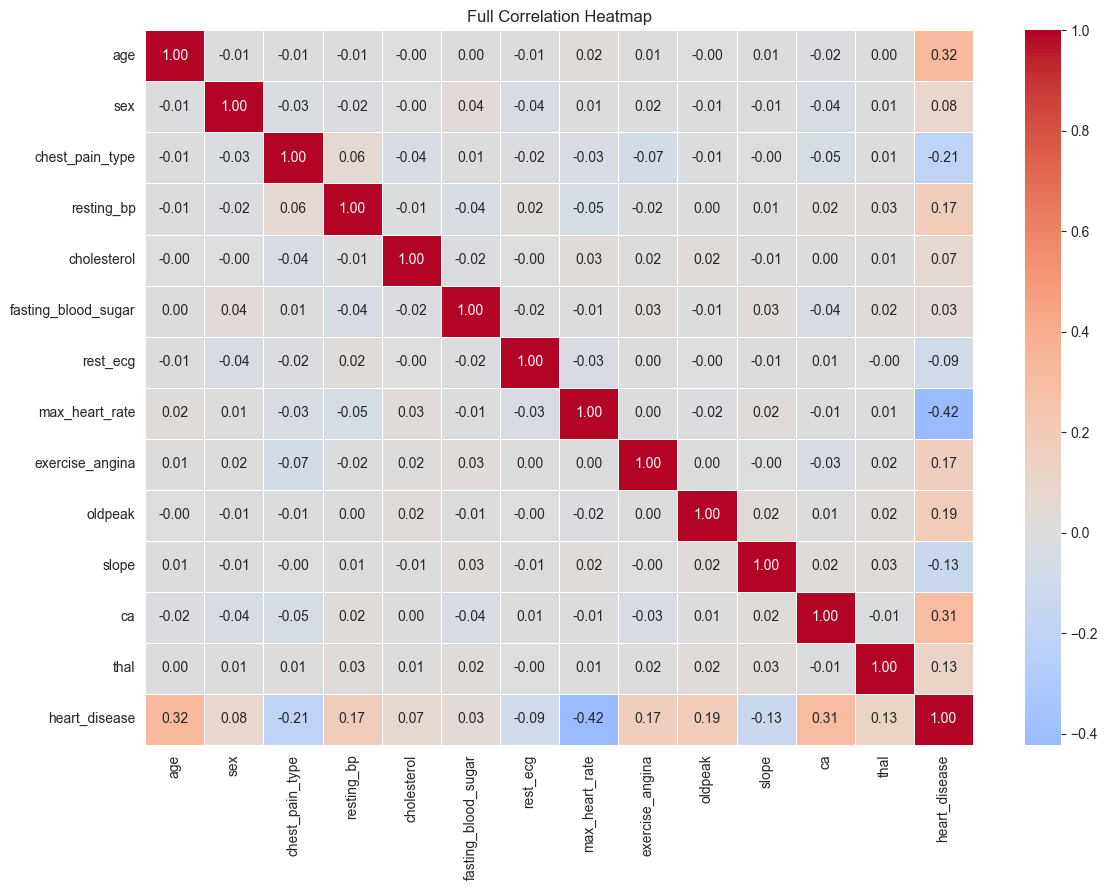

In [10]:
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Full Correlation Heatmap')
plt.tight_layout()
plt.show()

## 7. Outlier Detection (IQR)

age: 0 outliers (0.0%)
resting_bp: 0 outliers (0.0%)
cholesterol: 0 outliers (0.0%)
max_heart_rate: 0 outliers (0.0%)
oldpeak: 0 outliers (0.0%)


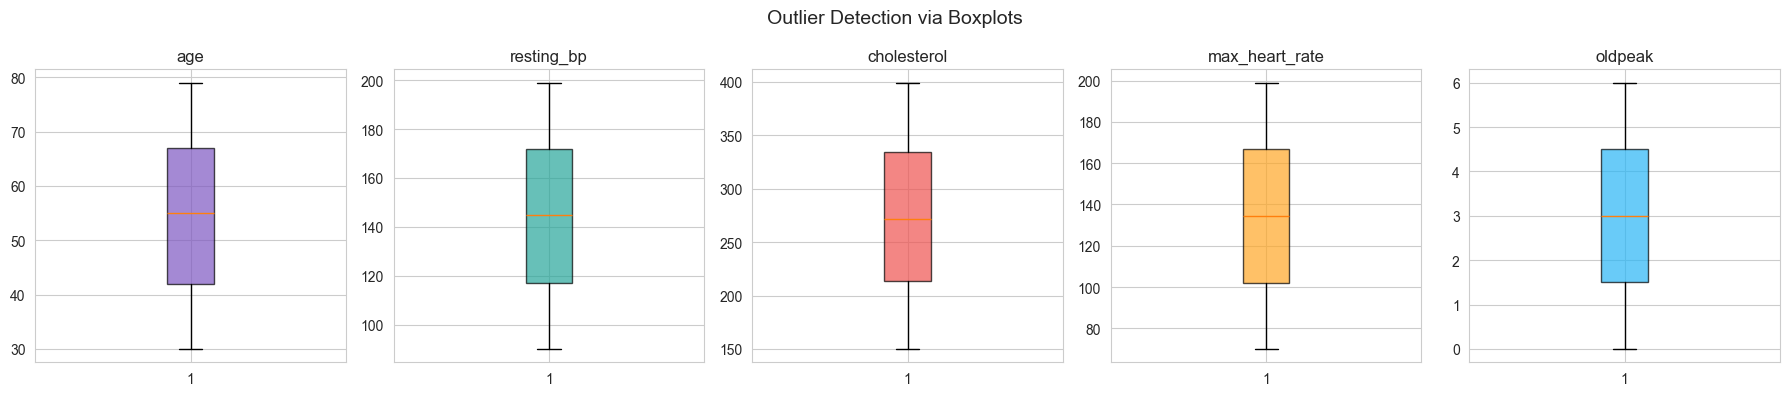

In [11]:
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col, color in zip(axes, num_cols, palette):
    ax.boxplot(df[col], patch_artist=True, boxprops=dict(facecolor=color, alpha=0.7))
    ax.set_title(col)
plt.suptitle('Outlier Detection via Boxplots', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Pairplot (Key Numerical Features)

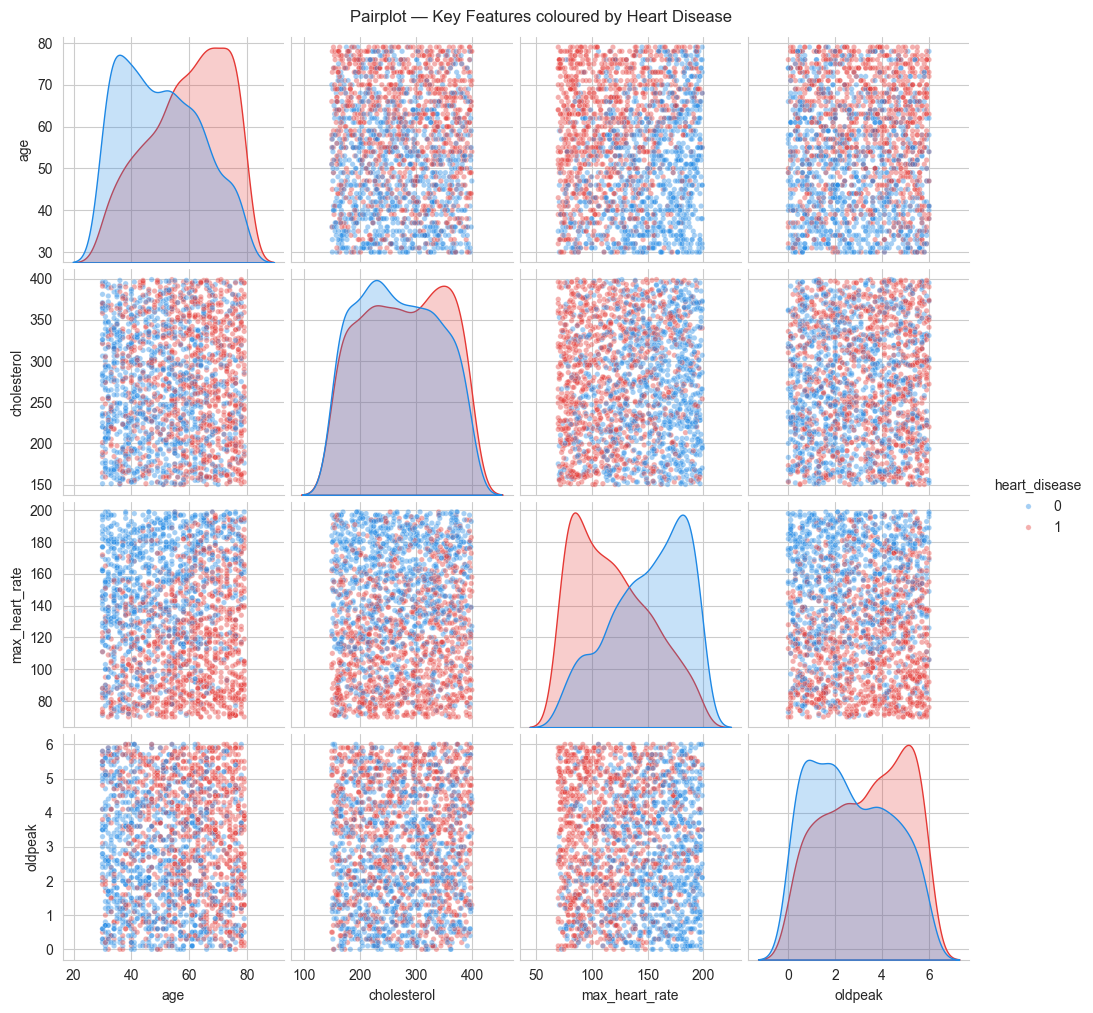

In [12]:
pair_cols = ['age', 'cholesterol', 'max_heart_rate', 'oldpeak', 'heart_disease']
g = sns.pairplot(df[pair_cols], hue='heart_disease',
                 palette={0: '#1E88E5', 1: '#E53935'},
                 plot_kws={'alpha': 0.4, 's': 15},
                 diag_kind='kde')
g.fig.suptitle('Pairplot — Key Features coloured by Heart Disease', y=1.01)
plt.show()